In [2]:
import sys
from dotenv import load_dotenv
import os

load_dotenv(override=True)

if "../app/" not in sys.path:
    sys.path.append("../app/")

print(sys.path)

['/usr/lib/python312.zip', '/usr/lib/python3.12', '/usr/lib/python3.12/lib-dynload', '', '/home/ryanwtsai/repos/lms-ai-agent/notebooks/venv/lib/python3.12/site-packages', '../app/']


In [7]:
collection_name = "test"

In [4]:
from pathlib import Path

files_dict = {}
file_exts = [".txt", ".html", ".vtt", ".md", ".pdf", ".pptx", ".ipynb"]
for ext in file_exts:
    files_dict[ext] = list(Path(".").glob(f"Content/**/*{ext}"))

files = [v[0] for k, v in files_dict.items() if len(v) > 0]
files

[PosixPath('Content/Data wrangling with Python/Exercise_Part_3_Pandas Index.html'),
 PosixPath('Content/AWS introduction/connecting-aws-ec2-with-session-manager.md'),
 PosixPath('Content/Excel Fundamental (self-paced)/Excel.pdf'),
 PosixPath('Content/AWS introduction/AWS VPC & Networking.pptx'),
 PosixPath('Content/Data wrangling with Python/Class 7 - Advanced Pandas_Solutions.ipynb')]

In [11]:
from haystack_utilities.pipelines import indexing_pipeline_lambda

# sentence-transformers/all-mpnet-base-v2
# Max tokens = 384
# Roughly 288 words (3 words = 4 tokens)
# 'fixed250'
splitting_options = {
    "split_strategy": "fixed",
    "split_by": "word",
    "split_length": 250,
    "split_overlap": 50,
    "split_threshold": 30,
    "respect_sentence_boundary": True
}

skip_cleaner=True
index_pipe = indexing_pipeline_lambda.build_indexing_pipeline(collection_name, splitting_options, skip_cleaner=skip_cleaner, max_content_len_chars=65535, drop_old=True)

Some secret values are not encrypted. Please use `Secret` class to encrypt them. The best way to implement it is to use `Secret.from_env` to load from environment variables. For example:
from haystack.utils import Secret
token = Secret.from_env('YOUR_TOKEN_ENV_VAR_NAME')


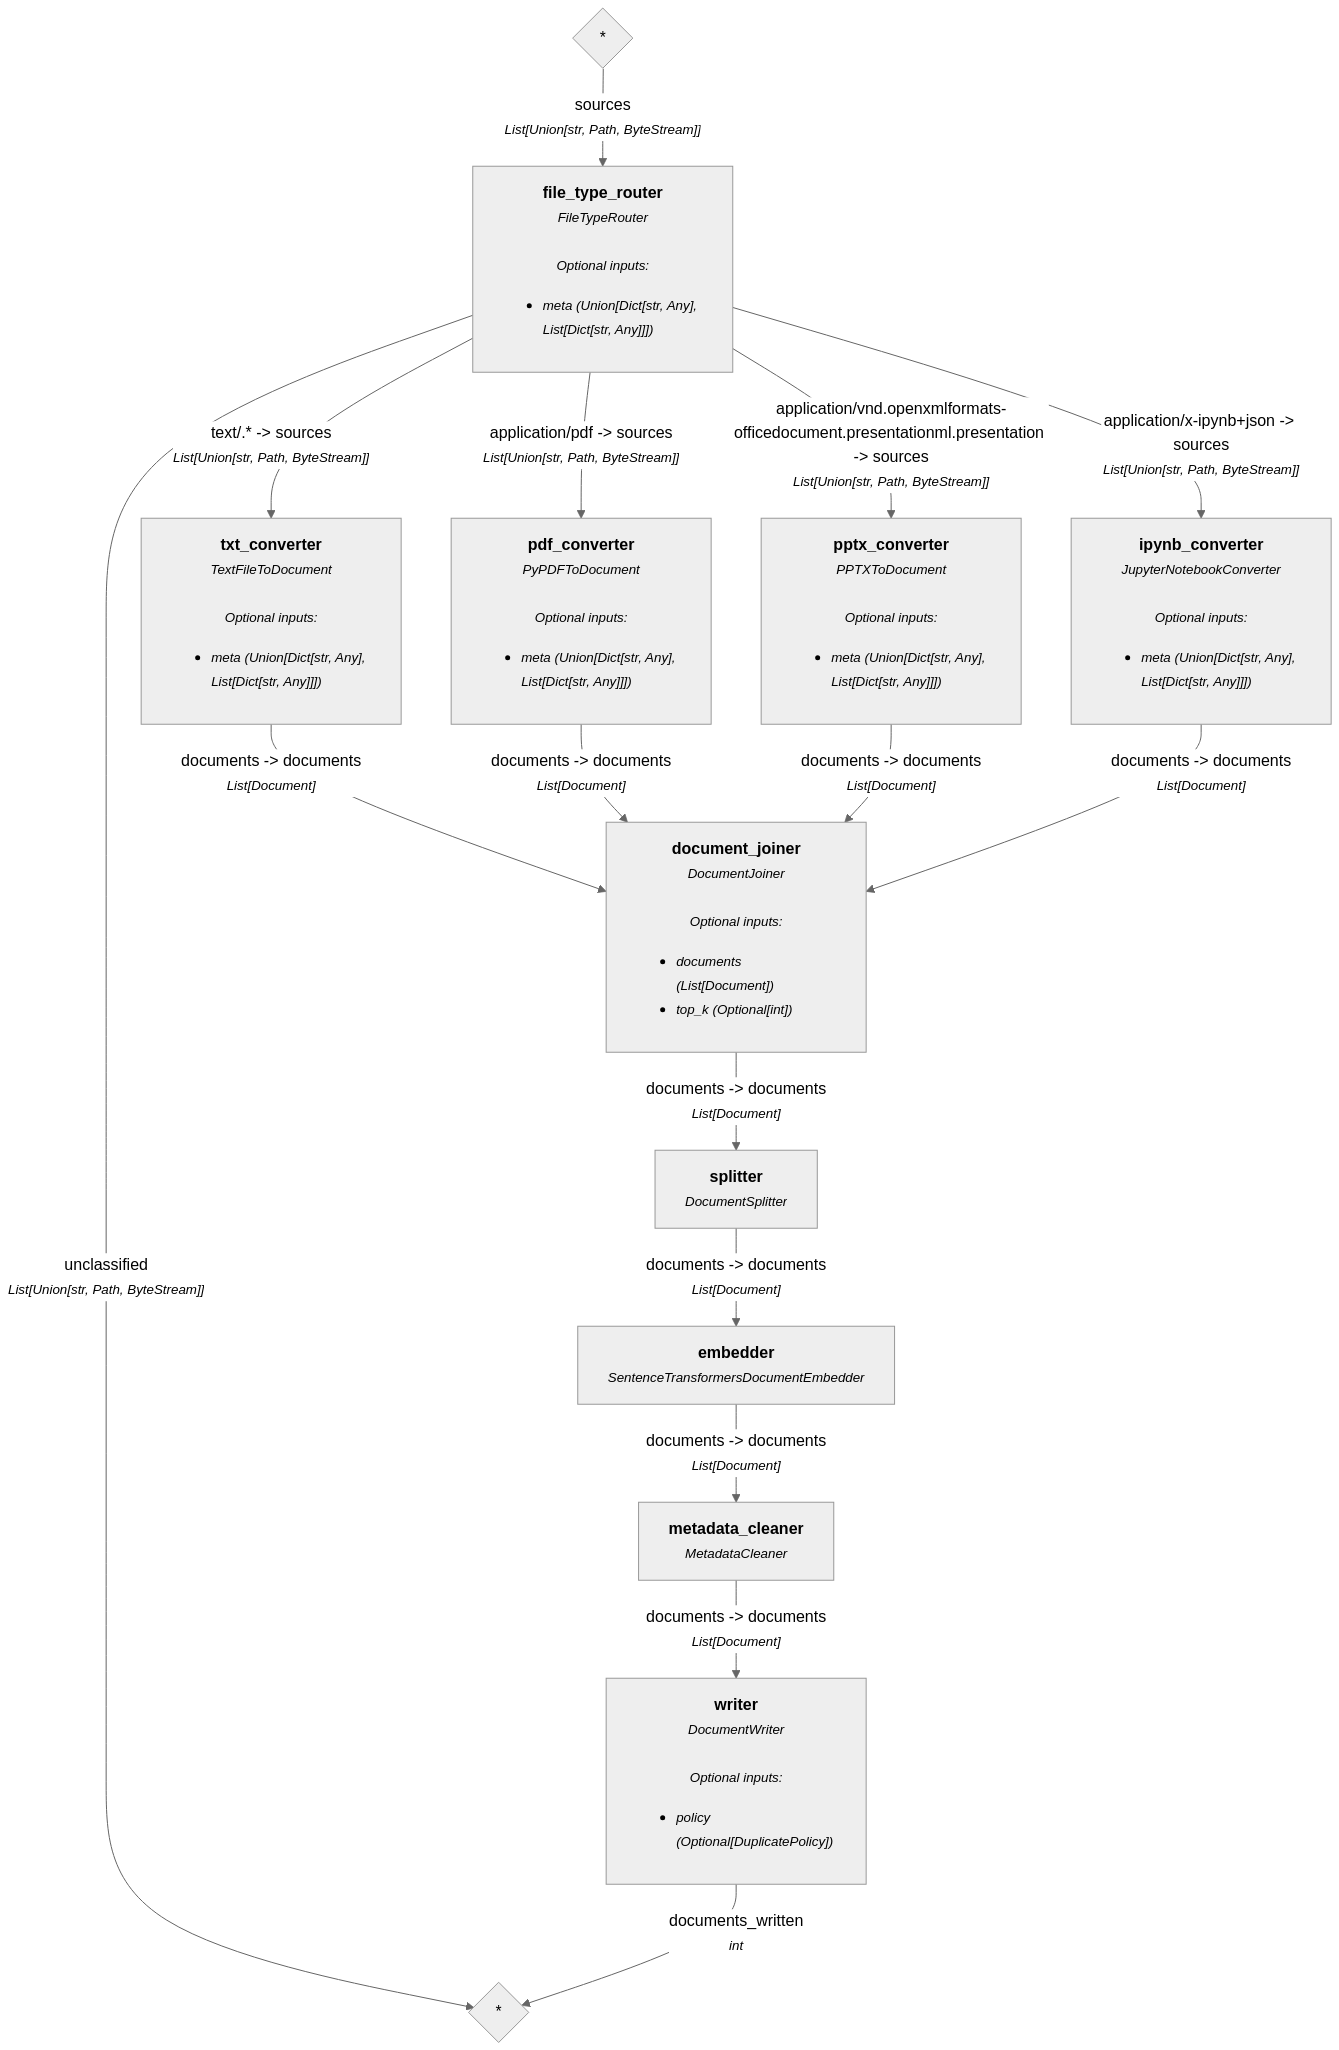

In [12]:
index_pipe.show()

In [14]:
index_pipe.remove_component("writer")

Inputs:
  - documents: List[Document]
  - policy: Optional[DuplicatePolicy]
Outputs:
  - documents_written: int

In [15]:
index_pipe

🚅 Components
  - file_type_router: FileTypeRouter
  - txt_converter: TextFileToDocument
  - pdf_converter: PyPDFToDocument
  - pptx_converter: PPTXToDocument
  - ipynb_converter: JupyterNotebookConverter
  - document_joiner: DocumentJoiner
  - splitter: DocumentSplitter
  - metadata_cleaner: MetadataCleaner
  - embedder: SentenceTransformersDocumentEmbedder
🛤️ Connections
  - file_type_router.text/.* -> txt_converter.sources (List[Union[str, Path, ByteStream]])
  - file_type_router.application/pdf -> pdf_converter.sources (List[Union[str, Path, ByteStream]])
  - file_type_router.application/vnd.openxmlformats-officedocument.presentationml.presentation -> pptx_converter.sources (List[Union[str, Path, ByteStream]])
  - file_type_router.application/x-ipynb\+json -> ipynb_converter.sources (List[Union[str, Path, ByteStream]])
  - txt_converter.documents -> document_joiner.documents (List[Document])
  - pdf_converter.documents -> document_joiner.documents (List[Document])
  - pptx_converter

In [ ]:
index_results = index_pipe.run({"file_type_router": {"sources": files}}, include_outputs_from={"file_type_router", "txt_converter", "pdf_converter", "pptx_converter", "ipynb_converter", "document_joiner", "metadata_cleaner"})
index_results

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

In [40]:
print("file_type_router:")
print(index_results["file_type_router"])
print("-"*50)

for file_type in ["txt", "pdf", "pptx", "ipynb"]:
    print(f"{file_type}_converter:")
    for doc in index_results[f"{file_type}_converter"]["documents"]:
        print(doc.meta["file_path"])
    print("-"*50)

print("document_joiner:")
for doc in index_results["document_joiner"]["documents"]:
    print(doc.meta["file_path"])
print("-"*50)

counter = 0
for doc in index_results["metadata_cleaner"]["documents"]:
    if len(doc.content) > 65535:
        # print(doc.meta)
        with open("long_text.txt", "w") as file_obj:
            file_obj.write(doc.content)
    # if doc.meta["metadata"]["title"] == 'Exercise_Part_3_Pandas Index.html':
    #     # print(doc.meta["metadata"])
    #     counter += 1
    #     print(counter)
    #     # print(len(doc.content))

file_type_router:
{'text/.*': [PosixPath('Content/Data wrangling with Python/Exercise_Part_3_Pandas Index.html'), PosixPath('Content/AWS introduction/connecting-aws-ec2-with-session-manager.md')], 'application/pdf': [PosixPath('Content/Excel Fundamental (self-paced)/Excel.pdf')], 'application/vnd.openxmlformats-officedocument.presentationml.presentation': [PosixPath('Content/AWS introduction/AWS VPC & Networking.pptx')], 'application/x-ipynb\\+json': [PosixPath('Content/Data wrangling with Python/Class 7 - Advanced Pandas_Solutions.ipynb')]}
--------------------------------------------------
txt_converter:
Exercise_Part_3_Pandas Index.html
connecting-aws-ec2-with-session-manager.md
--------------------------------------------------
pdf_converter:
Excel.pdf
--------------------------------------------------
pptx_converter:
AWS VPC & Networking.pptx
--------------------------------------------------
ipynb_converter:
Class 7 - Advanced Pandas_Solutions.ipynb
------------------------------

Max len char = 94260
Min len char = 59


(array([124.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   1.]),
 array([5.90000e+01, 9.47910e+03, 1.88992e+04, 2.83193e+04, 3.77394e+04,
        4.71595e+04, 5.65796e+04, 6.59997e+04, 7.54198e+04, 8.48399e+04,
        9.42600e+04]),
 <BarContainer object of 10 artists>)

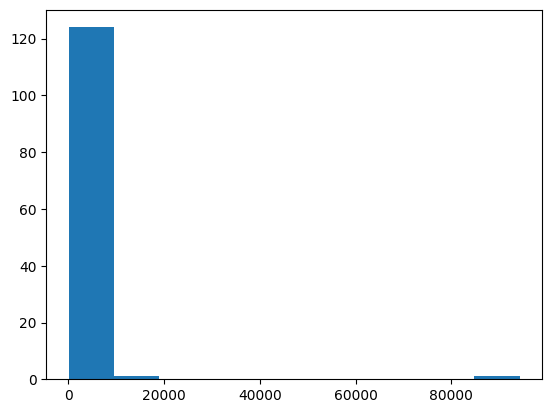

In [31]:
if "splitter" in index_results.keys():
    comp_name = "splitter"
elif "embedder" in index_results.keys():
    comp_name = "embedder"
elif "metadata_cleaner" in index_results.keys():
    comp_name = "metadata_cleaner"
else:
    comp_name = None

if comp_name:
    lengths = [len(doc.content) for doc in index_results[comp_name]["documents"]]
    print(f"Max len char = {max(lengths)}")
    print(f"Min len char = {min(lengths)}")

import matplotlib.pyplot as plt

plt.hist(lengths)

In [10]:
from haystack_utilities.tools import MilvusContextManager

with MilvusContextManager() as client:
    print(client.list_collections())
    client.drop_collection('ipynb_skipclean_fixed250_tag30_prompt15')
    # client.drop_collection('ipynb_skipclean_fixed250_tag30_prompt15')
    print(client.list_collections())

['ipynb_skipclean_fixed250_tag30_prompt17_all_ids', 'ipynb_skipclean_fixed250_tag30_prompt18', 'ipynb_test', 'ipynb_skipclean_fixed250_tag30_prompt15', 'pptx_fixed250_tag30_prompt14']
['ipynb_test', 'pptx_fixed250_tag30_prompt14', 'ipynb_skipclean_fixed250_tag30_prompt17_all_ids', 'ipynb_skipclean_fixed250_tag30_prompt18']
